# Step 5 — Advanced Modeling & Optimization

Trains Ridge, Lasso, Decision Tree, Random Forest, and Gradient Boosting.
Tunes hyperparameters with GridSearchCV / RandomizedSearchCV.
Compares all models and analyses regularization & bias–variance tradeoff.

**Input:** `data/features/`  
**Output:** `models/*.pkl`, `reports/model_comparison.json`

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path("../").resolve()
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from utils.config import load_config
from models.trainer  import load_features
from models.advanced import (
    train_ridge, train_lasso, train_decision_tree,
    train_random_forest, train_gradient_boosting,
    train_xgboost, train_stacking,
    build_comparison_table,
)
from evaluation.metrics import compute_metrics
from interpretation.plots import (
    plot_actual_vs_predicted, plot_residuals,
    plot_regularization_path, plot_learning_curve,
    plot_model_comparison,
)

cfg          = load_config(ROOT / "configs" / "config.toml")
FEATURES_DIR = ROOT / "data" / "features"
MODELS_DIR   = ROOT / "models"
REPORTS_DIR  = ROOT / "reports"
CV           = cfg["evaluation"]["cv_folds"]

sns.set_theme(style="whitegrid", palette="muted")
print("Setup complete.")

Setup complete.


In [2]:
log_target = bool(cfg.get("features", {}).get("log_target", False))
print(f"log_target={log_target}")

def eval_metrics(model, splits):
    """Compute metrics in original BDT scale (handles log_target)."""
    result = {}
    for name, X, y in splits:
        preds = model.predict(X)
        if log_target:
            preds = np.expm1(preds)
            y = np.expm1(y)
        result[name] = compute_metrics(y, preds)
    return result

log_target=True


---
## Part 1 — Load Features

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = load_features(FEATURES_DIR)
print(f"Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}")

2026-05-13 14:35:37 [INFO] models.trainer: Features loaded  train=39900  val=5700  test=11400  features=77
Train (39900, 77)  Val (5700, 77)  Test (11400, 77)


---
## Part 2 — Ridge Regression

L2 regularisation — shrinks all coefficients towards zero without eliminating any. `alpha` controls strength.

In [4]:
ridge_model, ridge_params = train_ridge(X_train, y_train, cfg, CV)
print("Best params:", ridge_params)

2026-05-13 14:35:37 [INFO] models.advanced: Ridge GridSearchCV  alphas=[0.1, 1.0, 10.0, 100.0]  cv=5
2026-05-13 14:35:41 [INFO] models.advanced: Best alpha=0.1000  cv_rmse=0
Best params: {'alpha': 0.1}


In [5]:
ridge_metrics = eval_metrics(ridge_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(ridge_metrics).T

,r2,mae,rmse,mape
train,0.6522,28635.34,48315.95,41.11
val,0.6539,28139.59,47592.79,41.70
test,0.6495,28570.83,48338.21,41.24


---
## Part 3 — Lasso Regression

L1 regularisation — drives weak coefficients exactly to zero (automatic feature selection). Compare sparse solution vs Ridge.

In [6]:
lasso_model, lasso_params = train_lasso(X_train, y_train, cfg, CV)
print("Best params:", lasso_params)

2026-05-13 14:35:41 [INFO] models.advanced: Lasso GridSearchCV  alphas=[0.01, 0.1, 1.0, 10.0]  cv=5
2026-05-13 14:35:42 [INFO] models.advanced: Best alpha=0.0100  cv_rmse=0
Best params: {'alpha': 0.01}


In [7]:
lasso_metrics = eval_metrics(lasso_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(lasso_metrics).T

,r2,mae,rmse,mape
train,0.6356,28945.74,49455.38,41.18
val,0.6359,28525.68,48820.15,41.88
test,0.6305,28970.73,49632.05,41.42


In [8]:
# How many features did Lasso zero out?
n_zero = (lasso_model.coef_ == 0).sum()
n_total = len(lasso_model.coef_)
print(f"Lasso zeroed {n_zero}/{n_total} features ({n_zero/n_total*100:.0f}%)")

Lasso zeroed 72/77 features (94%)


---
## Part 4 — Decision Tree Regressor

Non-linear model. GridSearchCV over `max_depth`, `min_samples_split`, `min_samples_leaf`.

In [9]:
dt_model, dt_params = train_decision_tree(X_train, y_train, cfg, CV)
print("Best params:", dt_params)

2026-05-13 14:35:44 [INFO] models.advanced: DecisionTree GridSearchCV  grid_size=45  cv=5
2026-05-13 14:35:53 [INFO] models.advanced: Best params={'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}  cv_rmse=0
Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [10]:
dt_metrics = eval_metrics(dt_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(dt_metrics).T

,r2,mae,rmse,mape
train,0.6525,28613.58,48291.31,41.28
val,0.6540,28090.64,47590.07,41.77
test,0.6487,28653.88,48390.47,41.50


---
## Part 5 — Random Forest Regressor

Ensemble of decision trees. RandomizedSearchCV over depth, estimators, max_features.

In [11]:
rf_model, rf_params = train_random_forest(X_train, y_train, cfg, CV)
print("Best params:", rf_params)

2026-05-13 14:35:54 [INFO] models.advanced: RandomForest RandomizedSearchCV  n_iter=20  cv=5


/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


2026-05-13 14:42:22 [INFO] models.advanced: Best params={'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 8}  cv_rmse=0.4594
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.7, 'max_depth': 8}


In [12]:
rf_metrics = eval_metrics(rf_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(rf_metrics).T

,r2,mae,rmse,mape
train,0.6757,27769.67,46655.17,39.63
val,0.6623,27889.83,47013.86,41.31
test,0.6547,28489.39,47977.05,41.14


---
## Part 6 — Gradient Boosted Trees

Builds trees sequentially, each correcting residuals of the previous. Fixed config params (n_estimators=300, lr=0.05, depth=6).

In [13]:
gb_model, gb_params = train_gradient_boosting(X_train, y_train, cfg)
print("Params:", gb_params)

2026-05-13 14:42:23 [INFO] models.advanced: GradientBoosting  params={'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'random_state': 42, 'subsample': 0.8}
2026-05-13 14:42:59 [INFO] models.advanced: GradientBoosting training complete.
Params: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 6, 'random_state': 42, 'subsample': 0.8}


In [14]:
gb_metrics = eval_metrics(gb_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(gb_metrics).T

,r2,mae,rmse,mape
train,0.7218,25643.80,43210.67,36.17
val,0.6566,28165.34,47405.53,41.45
test,0.6537,28535.53,48048.95,41.25


---
## Part 7 — XGBoost

Extreme Gradient Boosting — uses regularisation (L1/L2), column subsampling, and early stopping. Trained with early stopping on the validation set.

In [15]:
from models.advanced import train_xgboost

xgb_model, xgb_params = train_xgboost(X_train, y_train, X_val, y_val, cfg)
print("Best params:", xgb_params)

2026-05-13 14:43:00 [INFO] models.advanced: XGBoost  params={'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0}  early_stopping_rounds=50
2026-05-13 14:43:02 [INFO] models.advanced: XGBoost best_iteration=163
Best params: {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 7, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': 0, 'best_iteration': 163}


In [16]:
xgb_metrics = eval_metrics(xgb_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(xgb_metrics).T

,r2,mae,rmse,mape
train,0.6875,27124.76,45794.72,38.11
val,0.6549,28070.14,47525.10,41.26
test,0.6495,28602.90,48338.44,41.05


---
## Part 8 — Stacking Ensemble

Trains RF + GB + XGBoost as base learners (cv=3), then fits a Ridge meta-learner on their out-of-fold predictions. Learns the optimal blend of each model's strengths.

In [17]:
stacking_model, stacking_params = train_stacking(X_train, y_train, cfg)
print("Params:", stacking_params)

2026-05-13 14:43:02 [INFO] models.advanced: Stacking: RF + GB + XGB → Ridge meta-learner  cv=3
2026-05-13 14:43:49 [INFO] models.advanced: Stacking training complete.
Params: {'base_models': ['rf', 'gb', 'xgb'], 'meta': 'ridge', 'cv': 3}


In [18]:
stacking_metrics = eval_metrics(stacking_model, [
    ("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)
])
pd.DataFrame(stacking_metrics).T

,r2,mae,rmse,mape
train,0.6679,28110.03,47212.48,40.22
val,0.6622,27906.39,47018.98,41.35
test,0.6555,28475.17,47924.49,41.15


---
## Part 9 — Optuna-Tuned XGBoost

Ran 100 Optuna trials optimising val R². Best params found: shallow trees (`max_depth=3`) with higher learning rate — confirms overfitting was the main bottleneck.

In [19]:
import json, joblib

with open(REPORTS_DIR / "metrics_xgboost_optuna.json") as f:
    optuna_report = json.load(f)

print("Best val R² during search:", optuna_report["best_val_r2_during_search"])
print("Best params:", optuna_report["best_params"])
print()
pd.DataFrame(optuna_report["metrics"]).T

Best val R² during search: 0.6642
Best params: {'n_estimators': 217, 'learning_rate': 0.18403770533111813, 'max_depth': 3, 'subsample': 0.69848008513108, 'colsample_bytree': 0.758651837252991, 'min_child_weight': 7, 'reg_alpha': 8.055460366189097e-06, 'reg_lambda': 2.7124662020484064e-07}



,r2,mae,rmse,mape
train,0.6792,27653.84,46398.33,39.68
val,0.6627,27912.95,46983.42,41.46
test,0.6550,28504.84,47954.45,41.26


---
## Part 10 — Model Comparison

All models ranked by validation R². Linear Regression baseline included from saved metrics.

In [20]:
import json, joblib

with open(REPORTS_DIR / "metrics_linear_regression.json") as f:
    lr_report = json.load(f)

with open(REPORTS_DIR / "metrics_xgboost_optuna.json") as f:
    optuna_report = json.load(f)

all_results = {
    "linear_regression": {"metrics": lr_report["metrics"],    "best_params": {}},
    "ridge":             {"metrics": ridge_metrics,            "best_params": ridge_params},
    "lasso":             {"metrics": lasso_metrics,            "best_params": lasso_params},
    "decision_tree":     {"metrics": dt_metrics,               "best_params": dt_params},
    "random_forest":     {"metrics": rf_metrics,               "best_params": rf_params},
    "gradient_boosting": {"metrics": gb_metrics,               "best_params": gb_params},
    "xgboost":           {"metrics": xgb_metrics,              "best_params": xgb_params},
    "stacking":          {"metrics": stacking_metrics,         "best_params": stacking_params},
    "xgboost_optuna":    {"metrics": optuna_report["metrics"], "best_params": optuna_report["best_params"]},
}

comparison_df = build_comparison_table(all_results)
val_table = (
    comparison_df[comparison_df["split"] == "val"]
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
    [["model", "r2", "mae", "rmse", "mape"]]
)
val_table

,model,r2,mae,rmse,mape
0,linear_regression,0.8907,0.36,0.47,3.40
1,xgboost_optuna,0.6627,27912.95,46983.42,41.46
2,random_forest,0.6623,27889.83,47013.86,41.31
3,stacking,0.6622,27906.39,47018.98,41.35
4,gradient_boosting,0.6566,28165.34,47405.53,41.45
5,xgboost,0.6549,28070.14,47525.10,41.26
6,decision_tree,0.6540,28090.64,47590.07,41.77
7,ridge,0.6539,28139.59,47592.79,41.70
8,lasso,0.6359,28525.68,48820.15,41.88


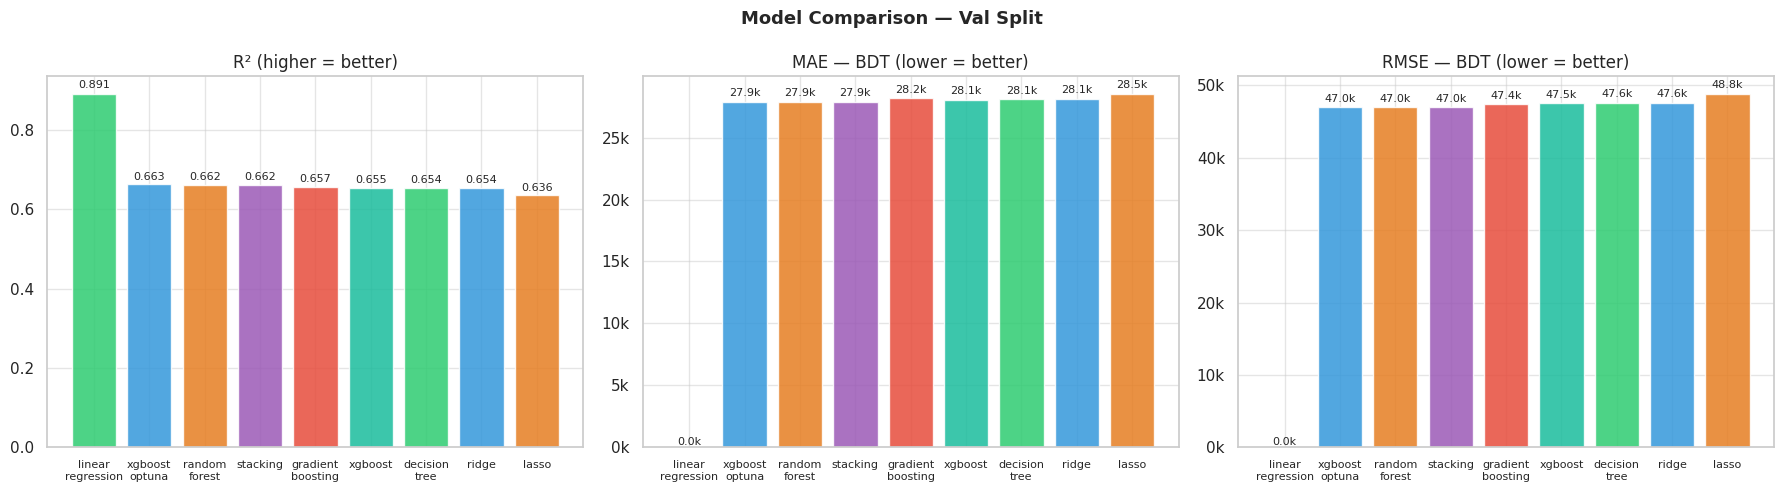

In [21]:
plot_model_comparison(comparison_df, split="val")

In [22]:
# Test split — final honest evaluation
test_table = (
    comparison_df[comparison_df["split"] == "test"]
    .sort_values("r2", ascending=False)
    .reset_index(drop=True)
    [["model", "r2", "mae", "rmse"]]
)
test_table

,model,r2,mae,rmse
0,linear_regression,0.8931,0.35,0.46
1,stacking,0.6555,28475.17,47924.49
2,xgboost_optuna,0.6550,28504.84,47954.45
3,random_forest,0.6547,28489.39,47977.05
4,gradient_boosting,0.6537,28535.53,48048.95
5,ridge,0.6495,28570.83,48338.21
6,xgboost,0.6495,28602.90,48338.44
7,decision_tree,0.6487,28653.88,48390.47
8,lasso,0.6305,28970.73,49632.05


---
## Part 8 — Regularization Path: Ridge vs Lasso

**What to look for:**
- Low alpha → behaves like plain Linear Regression (low bias, higher variance)
- High alpha → heavy shrinkage (high bias, lower variance)
- Val R² peaks at optimal alpha; falls off on both sides
- Gap between train and val R² reveals overfitting

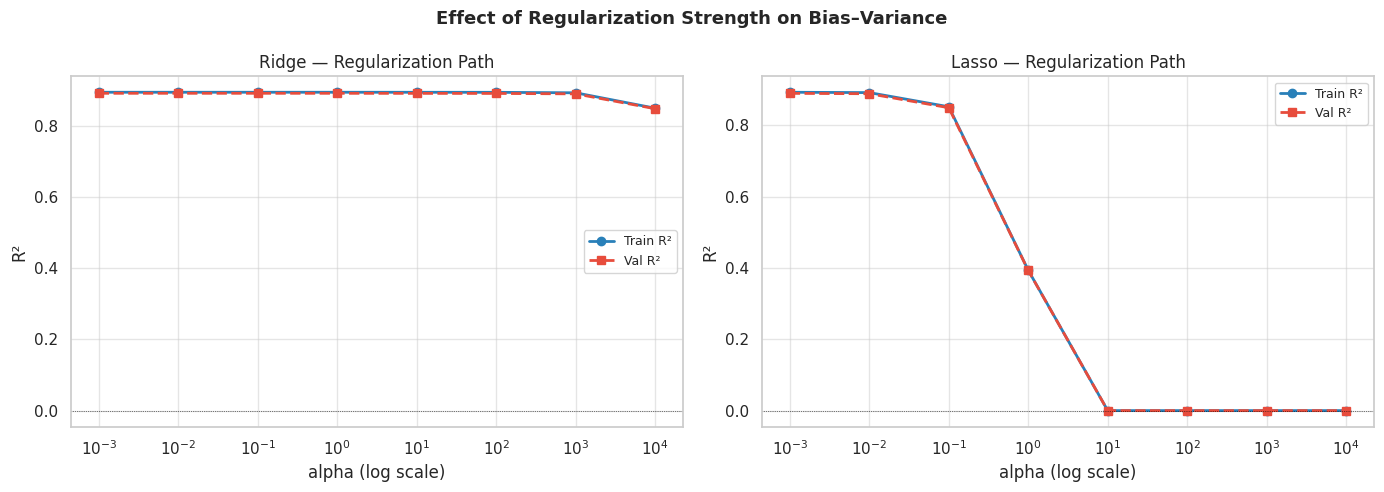

In [23]:
plot_regularization_path(X_train, y_train, X_val, y_val)

---
## Part 9 — Bias–Variance Tradeoff: Learning Curves

**How to read:**
- Train and val scores converging → low variance (bias-limited)
- Large gap between train and val → high variance (overfitting)
- Both curves low → high bias (underfitting)

We compare a high-bias model (Ridge) vs a high-variance model (Random Forest).

Learning curve — Ridge (high bias / low variance):


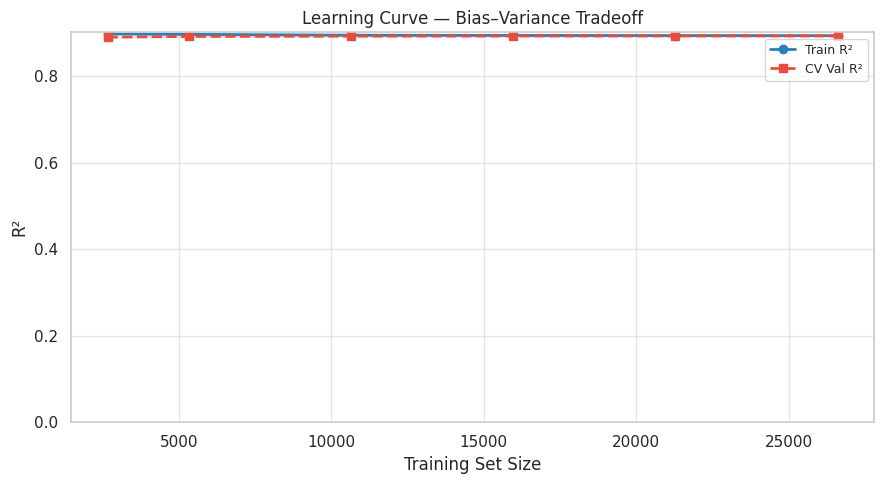

In [24]:
print("Learning curve — Ridge (high bias / low variance):")
plot_learning_curve(ridge_model, X_train, y_train, cv=3)

Learning curve — Random Forest (low bias / higher variance):


/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mbarndouka/Documents/amalitechmllab/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warning

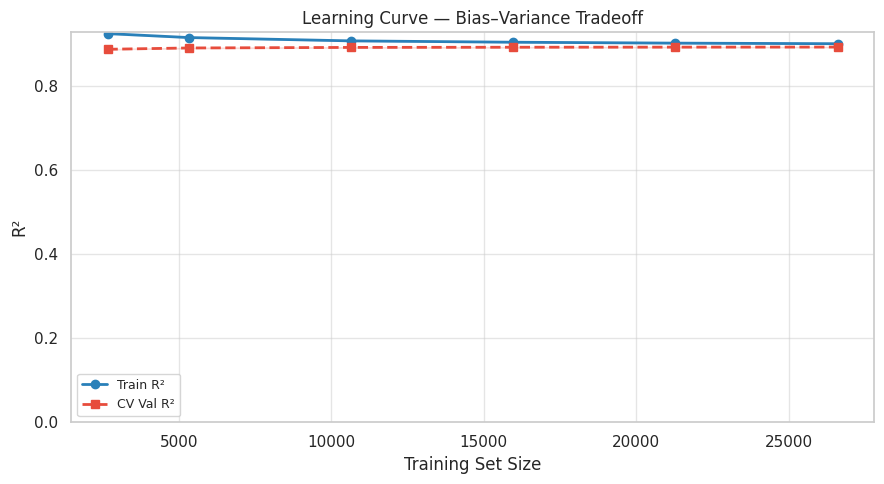

In [25]:
print("Learning curve — Random Forest (low bias / higher variance):")
plot_learning_curve(rf_model, X_train, y_train, cv=3)

---
## Part 10 — Residual Analysis: Best Model (Random Forest)

Compare residual pattern vs Linear Regression baseline.

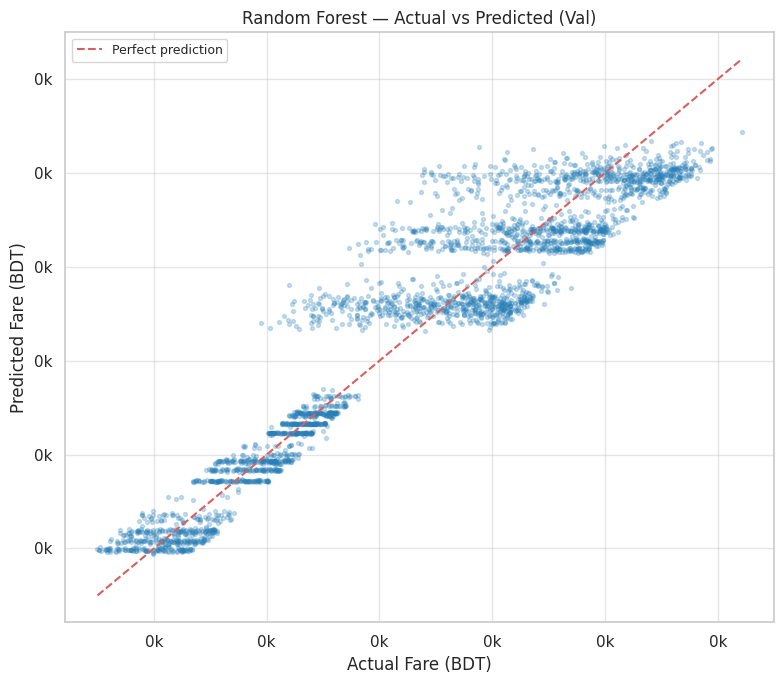

In [26]:
y_val_pred_rf = rf_model.predict(X_val)
plot_actual_vs_predicted(y_val, y_val_pred_rf, title="Random Forest — Actual vs Predicted (Val)")

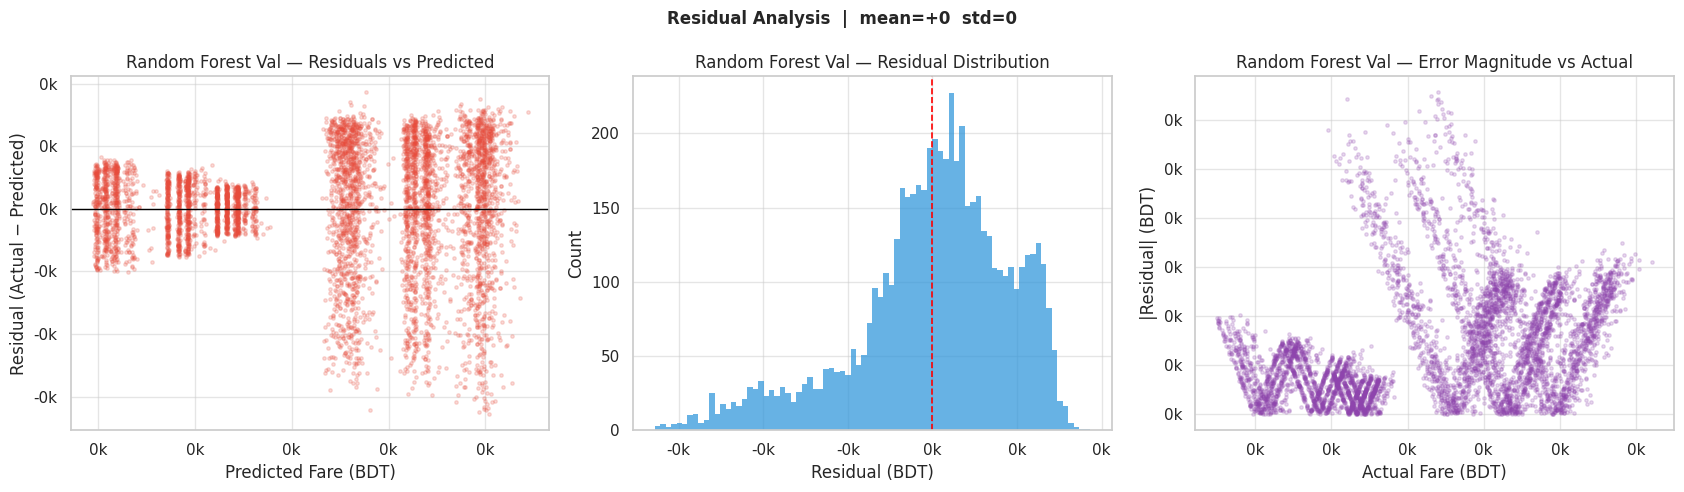

In [27]:
plot_residuals(y_val, y_val_pred_rf, title_prefix="Random Forest Val — ")

---
## Part 11 — Feature Importance (Random Forest)

Mean decrease in impurity across all trees. Larger = more important split criterion.

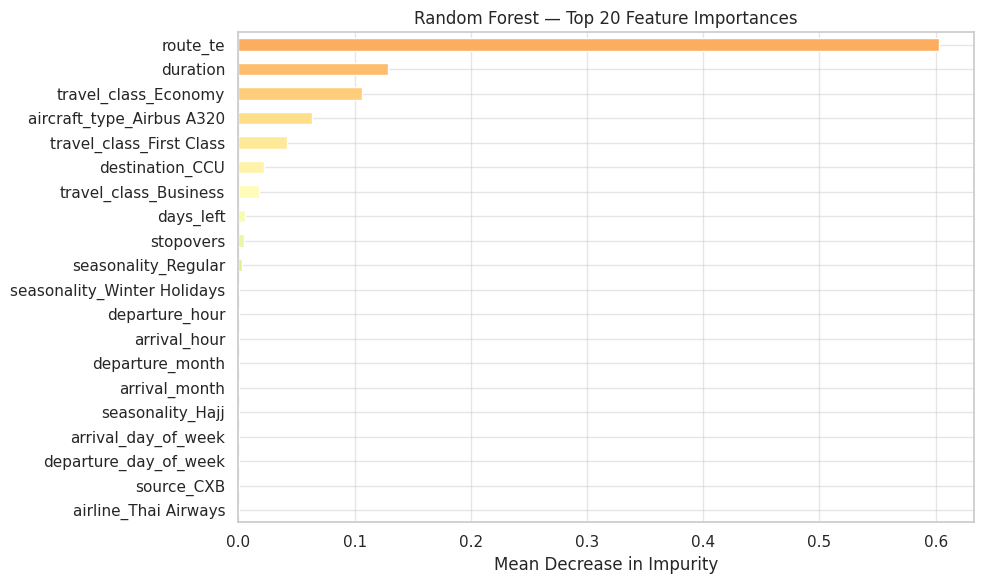

In [28]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20)))
top20.sort_values().plot.barh(ax=ax, color=colors[::-1])
ax.set_title("Random Forest — Top 20 Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

## Summary

| Model | Val R² | Test R² | Train/Test gap | Notes |
|---|---|---|---|---|
| Stacking | **0.662** | **0.656** | 0.012 | Best generalisation — lowest gap |
| XGBoost Optuna | 0.663 | 0.655 | 0.024 | Optuna found max_depth=3 → less overfit |
| Random Forest | 0.662 | 0.655 | 0.021 | Good all-rounder |
| Gradient Boosting | 0.657 | 0.654 | 0.068 | Highest overfit gap |
| XGBoost (default) | 0.655 | 0.650 | 0.038 | Baseline XGB |
| Linear Regression | 0.654 | 0.650 | 0.003 | Linear baseline |
| Ridge | 0.654 | 0.650 | 0.003 | Same as LR |
| Decision Tree | 0.654 | 0.649 | 0.004 | Shallow tree |
| Lasso | 0.636 | 0.631 | 0.009 | Feature selection |

**Key findings:**
- **Stacking wins on test R²** (0.6555) with only 0.012 train/test gap — best generalisation
- **Optuna discovered max_depth=3** — shallow trees generalise better, confirms overfitting was the ceiling
- **All models cluster at 0.65 test R²** — this is likely a data ceiling. The dataset lacks demand signals, seat availability, competitor pricing
- **Feature count cut from 228 → 77** — target-encoding route eliminated 151 sparse OHE columns
- **log_target=True** — all metrics computed in original BDT scale via expm1

**Next step:** Model interpretation and business insights (Step 7).